In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import time
import scienceplots

plt.style.use("science")

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging
logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [15]:
Bmin_G_K40 = 150
Bmax_G_K40 = 300
Bmin_G_K39 = 250
Bmax_G_K39 = 500
N_B = 1000
c_lines = "blue"
c_marker = "black"

In [16]:
def plot_a_sc(ax, B, FBres, **kwargs):
    a_sc = FBres.Getasc(B) / E9c.a0
    idx = util.find_sign_change(a_sc)
    return util.plot_in_ax_break_sign_change(ax, B, a_sc, idx, **kwargs)

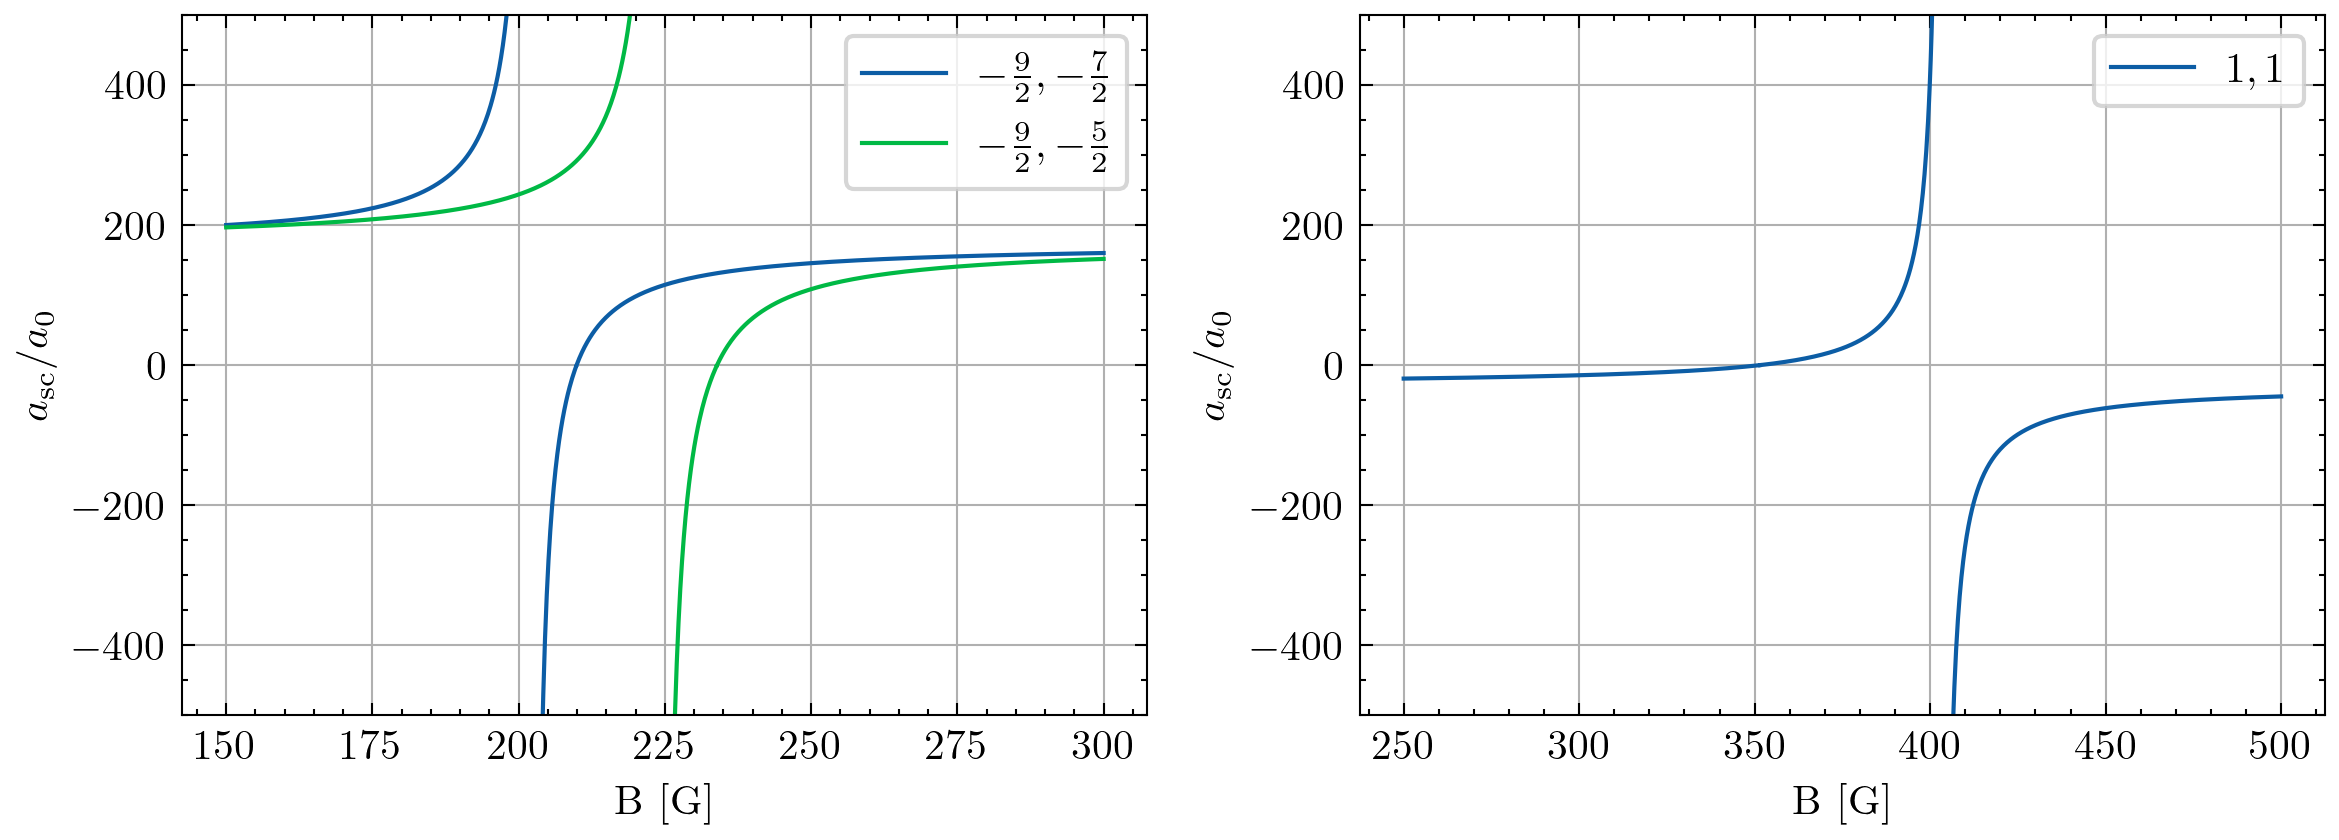

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (8, 3), dpi = 300)
K40_FB5o2 = E9a.FBres_K40_9o2_5o2
K40_FB7o2 = E9a.FBres_K40_9o2_7o2
K39_FB1 = E9a.FBres_K39_1_1

B_K40 = np.linspace(Bmin_G_K40, Bmax_G_K40, N_B)
l1 = plot_a_sc(axes[0], B_K40, K40_FB7o2, label = r"$-\frac{9}{2}, -\frac{7}{2}$")
l2 = plot_a_sc(axes[0], B_K40, K40_FB5o2, label = r"$-\frac{9}{2}, -\frac{5}{2}$")

B_K39 = np.linspace(Bmin_G_K39, Bmax_G_K39, N_B)
plot_a_sc(axes[1], B_K39, K39_FB1, label = r"$1, 1$")
for ax in axes:
    ax.grid("on")
    ax.legend(frameon = True)
    ax.set_ylim(-500, 500)
    ax.set_xlabel("B [G]")
    ax.set_ylabel(r"$a_{\mathrm{sc}}/a_0$")

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
file_full_path = Path(thesis_fig_path, "K_Feshbach.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')